<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/plant_classification_imagefolder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git lfs install
!git clone https://huggingface.co/datasets/Mirkat/Plant_Classification
import os


Git LFS initialized.
Cloning into 'Plant_Classification'...
remote: Enumerating objects: 2081, done.
remote: Total 2081 (delta 0), reused 0 (delta 0), pack-reused 2081 (from 1)
Receiving objects: 100% (2081/2081), 343.33 KiB | 4.40 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (2119/2119), done.
Filtering content: 100% (2109/2109), 54.69 MiB | 5.71 MiB/s, done.


In [2]:
# I want to create a dataset of images, labels
# let's start with the train folder
# Let's get all classes
root_dir = '/content/Plant_Classification/Plant Detection2.v10i.folder/train/'
all_classes = os.listdir(root_dir)
print(all_classes)

['tulip', 'poison ivy', 'Unlabeled', 'blueash', 'mint', 'rose', 'basil', 'poison oak', 'oregano', 'cilantro', 'oak leaves', 'boxelder', 'daisy', 'parsely']


In [3]:
import torchvision
from torchvision import datasets, models, transforms

In [4]:
# train and test transforms as defined by creators of Pre-trained NN
# Resize image to 70, 70
# Get a random crop of size 64, 64
# Convert the image to tensor
# Normalize the tensor as defined by mean and standard deviation
train_transform = torchvision.transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.RandomCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_transform = torchvision.transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.RandomCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])


In [9]:
data_dir = '/content/Plant_Classification/Plant Detection2.v10i.folder'
# Create training and testing datasets
train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'train'), transform=train_transform)


In [10]:

print(f"Number of images = {len(train_dataset)}")
print(f"Class names = {train_dataset.classes}")
print(f"Class to index mapping = {train_dataset.class_to_idx}")

Number of images = 1308
Class names = ['Unlabeled', 'basil', 'blueash', 'boxelder', 'cilantro', 'daisy', 'mint', 'oak leaves', 'oregano', 'parsely', 'poison ivy', 'poison oak', 'rose', 'tulip']
Class to index mapping = {'Unlabeled': 0, 'basil': 1, 'blueash': 2, 'boxelder': 3, 'cilantro': 4, 'daisy': 5, 'mint': 6, 'oak leaves': 7, 'oregano': 8, 'parsely': 9, 'poison ivy': 10, 'poison oak': 11, 'rose': 12, 'tulip': 13}


In [11]:
validation_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'valid'),
    transform=test_transform
)
print(f"Number of images = {len(validation_dataset)}")

Number of images = 539


In [12]:
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'test'),
    transform=test_transform
)
print(f"Number of images = {len(test_dataset)}")

Number of images = 268


In [13]:
# I love ImageFolder library, I don't need to create my own
# dataloader, it was fun to learn about creating one, but,
# this is easy to move forward from.

In [14]:
BATCH_SIZE = 16

In [15]:
import torch

In [16]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [17]:
for image, label in train_loader:
  print(f"Image batch size - {image.shape}")
  print(f"Label batch size - {label.shape}")
  print(f"Actual labels - {label[:10]}")
  break

Image batch size - torch.Size([16, 3, 64, 64])
Label batch size - torch.Size([16])
Actual labels - tensor([ 8, 12,  4,  4, 12,  6, 12, 13,  4,  4])


In [21]:
# Load pre-trained model
model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.DEFAULT)
model

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:02<00:00, 86.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
# Freeze the entire NN
for param in model.parameters():
  param.requires_grad = True



In [24]:
# Only fine tune the last 2 layers
for param in model.layer4[1:]:
  param.requires_grad = True



In [25]:
# Replace the last fully connected layer with a new layer
# The new layer consists on same in_features, but only
# the given number of plant's classes
model.fc = torch.nn.Linear(model.fc.in_features, len(train_dataset.classes))

In [26]:
def compute_accuracy(model, data_loader, device):
  """
  Return accuracy in % for given data_loader
  """
  with torch.no_grad():
    correct_predictions, total_examples = 0, 0

    for features, labels in data_loader:
      features = features.to(device)
      labels = labels.to(device)

      logits = model(features)
      # Returns value, indices
      _, predicted_labels = torch.max(logits, 1) # 1 means along the row

      total_examples += labels.size(0) # This is a single vector, to get single value
      correct_predictions += (predicted_labels == labels).sum()

    accuracy = 100 * correct_predictions / total_examples
  return accuracy

In [27]:
import time

In [28]:
def train_model(
    model,
    num_epochs,
    train_loader,
    validation_loader,
    test_loader,
    optimizer,
    device,
    scheduler=None,
    scheduler_on='valid_acc',
    logging_interval=10):
  start_time = time.time()
  minibatch_train_acc, train_acc_list, val_acc_list = [], [], []

  for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
      features = features.to(device)
      targets = targets.to(device)

      logits = model(features)
      loss = torch.nn.functional.cross_entropy(logits, targets)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Logging
      minibatch_train_acc.append(loss.item())
      # For every 50 batches, print log message
      if (batch_idx+1)%logging_interval == 0:
        print(f"Epoch = {epoch+1}/{num_epochs}; Batch = {batch_idx+1}/{len(train_loader)}; Loss = {loss}")

    # Let's get validation loss
    model.eval()
    with torch.no_grad():
      train_acc = compute_accuracy(model, train_loader, device)
      val_acc = compute_accuracy(model, validation_loader, device)
      train_acc_list.append(train_acc.item())
      val_acc_list.append(val_acc.item())
      print(f"Epoch = {epoch+1}/{num_epochs}; Train Accuracy = {train_acc}%; Validation Accuracy = {val_acc}%")

    # Total time elapsed during each epoch
    time_elapsed = time.time() - start_time
    print(f"Epoch time elapsed = {time_elapsed}")
    if scheduler is not None:
      if scheduler_on == 'valid_acc':
        scheduler.step(val_acc_list[-1])
      elif scheduler_on == 'minibatch_acc':
        scheduler.step(train_acc_list[-1])
      else:
        raise ValueError(f"Invalid {scheduler_on} choice")

  # Total training time elapsed
  total_time_elapsed = (time.time() - start_time)/60
  print(f"Total training time elapsed = {total_time_elapsed} min")

  # Test accuracy
  model.eval()
  with torch.no_grad():
    test_acc = compute_accuracy(model, test_loader, device)
    print(f"Test Accuracy = {test_acc}")

  return minibatch_train_acc, train_acc_list, val_acc_list

In [30]:
# Training the model
NUM_EPOCHS = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device = {device}")
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, verbose=True)

minibatch_acc_list, train_acc_list, validate_acc_list = train_model(model=model,
                                                                  num_epochs=NUM_EPOCHS,
                                                                  train_loader=train_loader,
                                                                  validation_loader=valid_loader,
                                                                    device=device,
                                                                  test_loader=test_loader,
                                                                    optimizer=optimizer,
                                                                    scheduler=scheduler,
                                                                    scheduler_on='valid_acc')

device = cpu


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch = 1/10; Batch = 10/82; Loss = 2.353888750076294
Epoch = 1/10; Batch = 20/82; Loss = 2.0500762462615967
Epoch = 1/10; Batch = 30/82; Loss = 2.609555959701538
Epoch = 1/10; Batch = 40/82; Loss = 1.9993139505386353
Epoch = 1/10; Batch = 50/82; Loss = 1.761673092842102
Epoch = 1/10; Batch = 60/82; Loss = 1.8514113426208496
Epoch = 1/10; Batch = 70/82; Loss = 2.088036298751831
Epoch = 1/10; Batch = 80/82; Loss = 1.845046043395996
Epoch = 1/10; Train Accuracy = 51.834861755371094; Validation Accuracy = 34.693878173828125
Epoch time elapsed = 391.5252032279968
Epoch = 2/10; Batch = 10/82; Loss = 1.6649696826934814
Epoch = 2/10; Batch = 20/82; Loss = 1.5876437425613403
Epoch = 2/10; Batch = 30/82; Loss = 1.957260012626648
Epoch = 2/10; Batch = 40/82; Loss = 1.3193179368972778
Epoch = 2/10; Batch = 50/82; Loss = 1.4753602743148804
Epoch = 2/10; Batch = 60/82; Loss = 1.7677793502807617
Epoch = 2/10; Batch = 70/82; Loss = 0.9712134599685669
Epoch = 2/10; Batch = 80/82; Loss = 1.256295561790

In [31]:
# imports from installed libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_training_loss(minibatch_loss_list, num_epochs, iter_per_epoch,
                       results_dir=None, averaging_iterations=100):

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_loss_list)),
             (minibatch_loss_list), label='Minibatch Loss')

    if len(minibatch_loss_list) > 1000:
        ax1.set_ylim([
            0, np.max(minibatch_loss_list[1000:])*1.5
            ])
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    ax1.plot(np.convolve(minibatch_loss_list,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode='valid'),
             label='Running Average')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(results_dir, 'plot_training_loss.pdf')
        plt.savefig(image_path)


def plot_accuracy(train_acc_list, valid_acc_list, results_dir):

    num_epochs = len(train_acc_list)

    plt.plot(np.arange(1, num_epochs+1),
             train_acc_list, label='Training')
    plt.plot(np.arange(1, num_epochs+1),
             valid_acc_list, label='Validation')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(
            results_dir, 'plot_acc_training_validation.pdf')
        plt.savefig(image_path)


def show_examples(model, data_loader, unnormalizer=None, class_dict=None):


    for batch_idx, (features, targets) in enumerate(data_loader):

        with torch.no_grad():
            features = features
            targets = targets
            logits = model(features)
            predictions = torch.argmax(logits, dim=1)
        break

    fig, axes = plt.subplots(nrows=3, ncols=5,
                             sharex=True, sharey=True)

    if unnormalizer is not None:
        for idx in range(features.shape[0]):
            features[idx] = unnormalizer(features[idx])
    nhwc_img = np.transpose(features, axes=(0, 2, 3, 1))

    if nhwc_img.shape[-1] == 1:
        nhw_img = np.squeeze(nhwc_img.numpy(), axis=3)

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhw_img[idx], cmap='binary')
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False

    else:

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhwc_img[idx])
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(conf_mat,
                          hide_spines=False,
                          hide_ticks=False,
                          figsize=None,
                          cmap=None,
                          colorbar=False,
                          show_absolute=True,
                          show_normed=False,
                          class_names=None):

    if not (show_absolute or show_normed):
        raise AssertionError('Both show_absolute and show_normed are False')
    if class_names is not None and len(class_names) != len(conf_mat):
        raise AssertionError('len(class_names) should be equal to number of'
                             'classes in the dataset')

    total_samples = conf_mat.sum(axis=1)[:, np.newaxis]
    normed_conf_mat = conf_mat.astype('float') / total_samples

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    if cmap is None:
        cmap = plt.cm.Blues

    if figsize is None:
        figsize = (len(conf_mat)*1.25, len(conf_mat)*1.25)

    if show_normed:
        matshow = ax.matshow(normed_conf_mat, cmap=cmap)
    else:
        matshow = ax.matshow(conf_mat, cmap=cmap)

    if colorbar:
        fig.colorbar(matshow)

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            cell_text = ""
            if show_absolute:
                cell_text += format(conf_mat[i, j], 'd')
                if show_normed:
                    cell_text += "\n" + '('
                    cell_text += format(normed_conf_mat[i, j], '.2f') + ')'
            else:
                cell_text += format(normed_conf_mat[i, j], '.2f')
            ax.text(x=j,
                    y=i,
                    s=cell_text,
                    va='center',
                    ha='center',
                    color="white" if normed_conf_mat[i, j] > 0.5 else "black")

    if class_names is not None:
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=90)
        plt.yticks(tick_marks, class_names)

    if hide_spines:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    if hide_ticks:
        ax.axes.get_yaxis().set_ticks([])
        ax.axes.get_xaxis().set_ticks([])

    plt.xlabel('predicted label')
    plt.ylabel('true label')
    return fig, ax

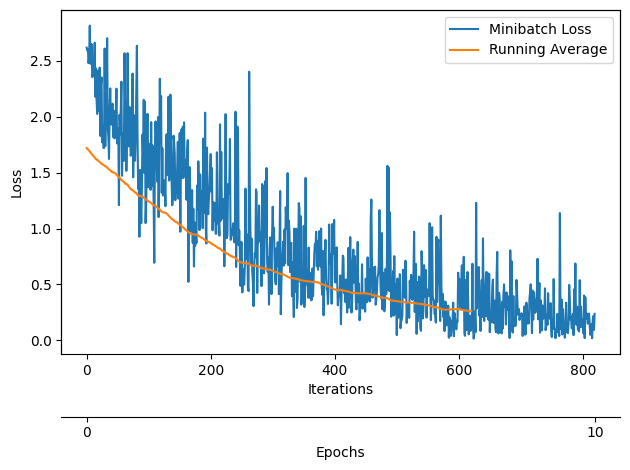

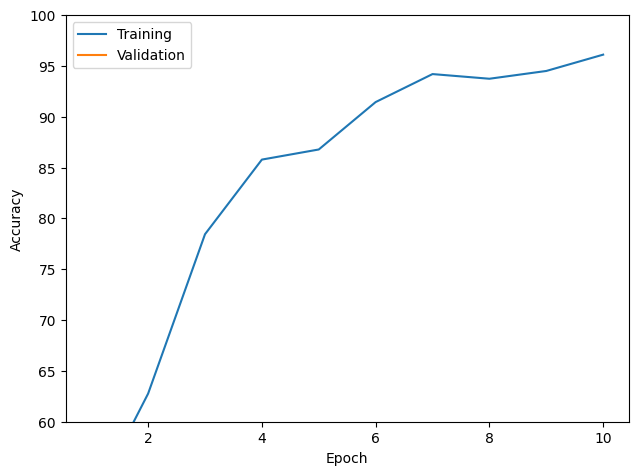

In [33]:
plot_training_loss(minibatch_loss_list=minibatch_acc_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=200)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=validate_acc_list,
              results_dir=None)
plt.ylim([60, 100])
plt.show()

In [34]:
# Normalized Value = (Original Value - Mean) / Standard Deviation
# Let's create an UnNormalizer
class UnNormalizer(object):
  def __init__(self, mean, std):
    self.mean = mean
    self.std = std

  def __clall__(self, tensor):
    for tsor, m, s in zip(tensor, self.mean, self.std):
      tsor.mul_(s).add_(m)
    return tensor


In [39]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Parameters:
        ------------
        tensor (Tensor): Tensor image of size (C, H, W) to be normalized.

        Returns:
        ------------
        Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

In [41]:
class_dict = train_dataset.class_to_idx
print(type(class_dict))
print(class_dict)

<class 'dict'>
{'Unlabeled': 0, 'basil': 1, 'blueash': 2, 'boxelder': 3, 'cilantro': 4, 'daisy': 5, 'mint': 6, 'oak leaves': 7, 'oregano': 8, 'parsely': 9, 'poison ivy': 10, 'poison oak': 11, 'rose': 12, 'tulip': 13}


In [42]:
print(test_loader.dataset.class_to_idx)

{'Unlabeled': 0, 'basil': 1, 'blueash': 2, 'boxelder': 3, 'cilantro': 4, 'daisy': 5, 'mint': 6, 'oak leaves': 7, 'oregano': 8, 'parsely': 9, 'poison ivy': 10, 'poison oak': 11, 'rose': 12, 'tulip': 13}


In [44]:
# imports from installed libraries
import os
import numpy as np
import random
import torch
from distutils.version import LooseVersion as Version
from itertools import product


def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def set_deterministic(use_tensorcores=False):
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

    if torch.__version__ <= Version("1.7"):
        torch.set_deterministic(True)
    else:
        torch.use_deterministic_algorithms(True)

        # The following are set to True by default and allow cards
        # like the Ampere and newer to utilize tensorcores for
        # convolutions and matrix multiplications, which can result
        # in a significant speed-up. However, results may differ compared
        # to card how don't use mixed precision via tensor cores.
        torch.backends.cuda.matmul.allow_tf32 = use_tensorcores
        torch.backends.cudnn.allow_tf32 = use_tensorcores


def compute_accuracy(model, data_loader, device):

    with torch.no_grad():

        correct_pred, num_examples = 0, 0

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.float().to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100


def compute_confusion_matrix(model, data_loader, device):

    all_targets, all_predictions = [], []
    with torch.no_grad():

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets
            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)
            all_targets.extend(targets.to('cpu'))
            all_predictions.extend(predicted_labels.to('cpu'))

    all_predictions = all_predictions
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    class_labels = np.unique(np.concatenate((all_targets, all_predictions)))
    if class_labels.shape[0] == 1:
        if class_labels[0] != 0:
            class_labels = np.array([0, class_labels[0]])
        else:
            class_labels = np.array([class_labels[0], 1])
    n_labels = class_labels.shape[0]
    lst = []
    z = list(zip(all_targets, all_predictions))
    for combi in product(class_labels, repeat=2):
        lst.append(z.count(combi))
    mat = np.asarray(lst)[:, None].reshape(n_labels, n_labels)
    return mat

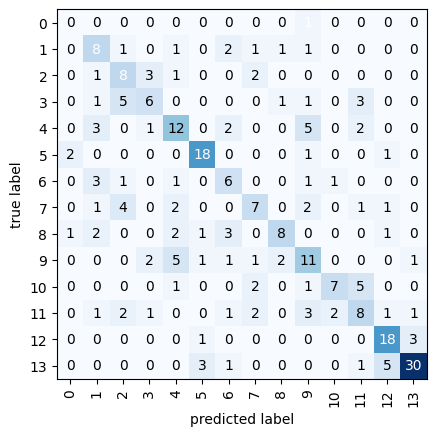

In [45]:
mat = compute_confusion_matrix(model=model, data_loader=test_loader, device=torch.device('cpu'))
plot_confusion_matrix(mat, class_names=class_dict.values())
plt.show()

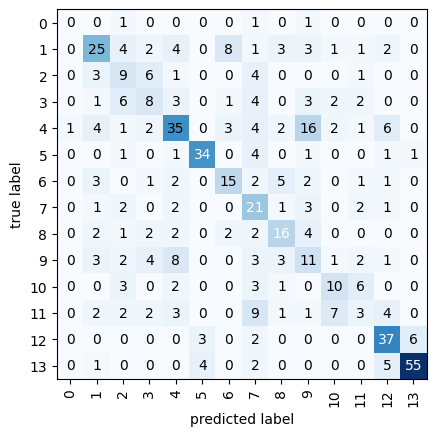

In [46]:
mat = compute_confusion_matrix(model=model, data_loader=valid_loader, device=torch.device('cpu'))
plot_confusion_matrix(mat, class_names=class_dict.values())
plt.show()

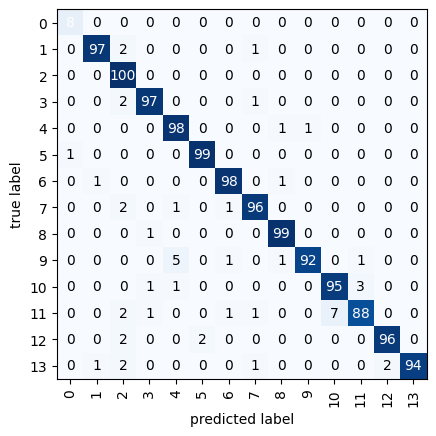

In [47]:
mat = compute_confusion_matrix(model=model, data_loader=train_loader, device=torch.device('cpu'))
plot_confusion_matrix(mat, class_names=class_dict.values())
plt.show()